In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq


#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


llm=ChatGroq(model="openai/gpt-oss-120b")


In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq


In [3]:
class BlogState(TypedDict):
    
    title: str
    outline: str
    content: str
    evaluate: int
    


In [4]:
def create_outline(state: BlogState) -> BlogState:
    
    ## fetch title from state
    title = state['title']
    
    # call llm gen outline 
    prompt = f'Generate a detailed outline for a blog post with the title: {title}'
    
    outline = llm.invoke(prompt).content
    
    # update state
    state['outline'] = outline
    
    return state

In [5]:
def create_blog(state: BlogState) -> BlogState:
    
    title = state['title']
    outline = state['outline']
    
    prompt = f"Write a comprehensive blog post based on the title: {title} and the following outline: {outline}"
    
    
    content = llm.invoke(prompt).content
    
    state['content'] = content
    return state
    

In [6]:
def evaluate_blog(state: BlogState) -> BlogState:
    
    content = state['content']
    outline = state['outline']
    
    prompt = f"Evaluate the following blog content based on the outline provided. Rate it from 1 to 10, where 10 means it perfectly follows the outline.\n\nOutline: {outline}\n\nContent: {content}\n\nProvide only the rating as an integer."
    
    evaluation = llm.invoke(prompt).content
    
    state['evaluate'] = int(evaluation.strip())
    
    return state

In [7]:
graph = StateGraph(BlogState)


# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('evaluate_blog', evaluate_blog)

## edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'evaluate_blog')
graph.add_edge('evaluate_blog', END)

workflow = graph.compile()

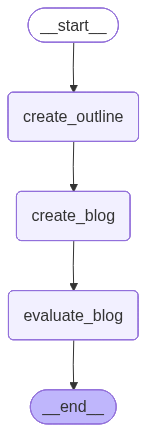

In [8]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [9]:
initial_state = {'title': "Rise of LLMs"}
final_state = workflow.invoke(initial_state)
final_state


{'title': 'Rise of LLMs',
 'outline': '**Blog Post Title:** *The Rise of Large Language Models (LLMs)*  \n\n---\n\n### 1. Introduction  \n- **Hook:** A compelling anecdote or statistic (e.g., “ChatGPT reached 100\u202fM users in just two months”).  \n- **Definition:** What is a Large Language Model?  \n- **Thesis Statement:** Explain that the post will trace the evolution, impact, challenges, and future trajectory of LLMs.  \n\n---\n\n### 2. Historical Foundations  \n#### 2.1 Early NLP Milestones  \n- Rule‑based systems (ELIZA, SHRDLU)  \n- Statistical methods (n‑grams, Hidden Markov Models)  \n\n#### 2.2 The Birth of Neural Language Models  \n- Word embeddings (Word2Vec, GloVe)  \n- Recurrent networks (RNN, LSTM, GRU)  \n\n#### 2.3 The Transformer Revolution (2017)  \n- “Attention is All You Need” – key concepts (self‑attention, positional encoding)  \n- Why transformers outperformed RNNs  \n\n---\n\n### 3. The Scaling Era – From GPT‑1 to GPT‑4 (and Beyond)  \n| Model | Parameters | T

In [10]:
print(final_state['content'])


# The Rise of Large Language Models (LLMs)

*Meta Title:* **The Rise of Large Language Models: History, Impact, and What’s Next**  
*Meta Description:* *Explore how transformer‑based LLMs like GPT‑4 transformed AI, their real‑world applications, ethical challenges, and future trends.*  
*Target Keywords:* large language models, rise of LLMs, GPT‑4, transformer models, AI applications, LLM ethics, future of AI  

---

## 1. Introduction  

**Hook:** In early November 2023, OpenAI announced that **ChatGPT had crossed the 100‑million‑user mark in just two months**—a milestone that would have taken the most successful social platforms years to achieve. The speed of that adoption is a vivid reminder that we are living through a paradigm shift in how machines understand and generate language.

**What is a Large Language Model?**  
A **Large Language Model (LLM)** is a neural‑network‑based system trained on massive text (and often multimodal) datasets that can predict the next token in a sequ

In [11]:
print(final_state['outline'])

**Blog Post Title:** *The Rise of Large Language Models (LLMs)*  

---

### 1. Introduction  
- **Hook:** A compelling anecdote or statistic (e.g., “ChatGPT reached 100 M users in just two months”).  
- **Definition:** What is a Large Language Model?  
- **Thesis Statement:** Explain that the post will trace the evolution, impact, challenges, and future trajectory of LLMs.  

---

### 2. Historical Foundations  
#### 2.1 Early NLP Milestones  
- Rule‑based systems (ELIZA, SHRDLU)  
- Statistical methods (n‑grams, Hidden Markov Models)  

#### 2.2 The Birth of Neural Language Models  
- Word embeddings (Word2Vec, GloVe)  
- Recurrent networks (RNN, LSTM, GRU)  

#### 2.3 The Transformer Revolution (2017)  
- “Attention is All You Need” – key concepts (self‑attention, positional encoding)  
- Why transformers outperformed RNNs  

---

### 3. The Scaling Era – From GPT‑1 to GPT‑4 (and Beyond)  
| Model | Parameters | Training Data | Release Year | Notable Capabilities |
|-------|---------

In [12]:
print(final_state['evaluate'])

10
